# Retail Sales Forecasting

A machine learning model that forecasts daily store sales using historical patterns, promotions, and store characteristics built to demonstrate demand forecasting for retail inventory and staffing planning.

## Problem Statement

Retailers need to anticipate demand to plan inventory, staffing, and promotions effectively. This project builds a forecasting model using real daily sales data from a retail chain (Rossmann), predicting sales several weeks into the future based on each store's own historical patterns.

## Data Source

Rossmann Store Sales dataset (Kaggle) — daily sales data for 1,115 stores from January 2013 to July 2015, along with store metadata (type, assortment, competition, promotions).

## Approach

1. Clean and merge sales and store data
2. Explore seasonality, promotion effects, and store characteristics
3. Engineer calendar-aware lag and rolling features
4. Split data temporally (not randomly) for honest forecasting evaluation
5. Train and compare baseline, Linear Regression, Random Forest, and Gradient Boosting models
6. Evaluate performance over time, by store segment, and via feature importance

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import os

pd.set_option('display.max_columns', None)

In [2]:
from google.colab import files
uploaded = files.upload()

Saving store.csv to store (1).csv
Saving train.csv.zip to train.csv (1).zip


In [3]:
import os
os.makedirs('data/raw', exist_ok=True)

for filename, content in uploaded.items():
    target_path = os.path.join('data/raw', filename)
    with open(target_path, 'wb') as f:
        f.write(content)


In [4]:
import zipfile

with zipfile.ZipFile('data/raw/train.csv.zip', 'r') as z:
    z.extractall('data/raw/')
!ls data/raw/

'store (1).csv'   store.csv   train.csv  'train.csv (1).zip'   train.csv.zip


In [6]:
sales_df = pd.read_csv('data/raw/train.csv')
store_df = pd.read_csv('data/raw/store.csv')

print("Sales:", sales_df.shape)
print("Store:", store_df.shape)

Sales: (1017209, 9)
Store: (1115, 10)


/tmp/ipykernel_11968/2419087383.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  sales_df = pd.read_csv('data/raw/train.csv')


## Data Cleaning

Key issues addressed:
- `StateHoliday` contained a mix of string and integer types representing the same category, causing inconsistent grouping
- Closed-store days (`Open=0`) always have zero sales by definition and were excluded, since a forecasting model should learn genuine demand patterns, not simply replicate a known "closed" business rule

In [7]:
# Fix mixed-type StateHoliday column
sales_df['StateHoliday'] = sales_df['StateHoliday'].astype(str).str.strip()
print(sales_df['StateHoliday'].value_counts())

StateHoliday
0    986159
a     20260
b      6690
c      4100
Name: count, dtype: int64


In [8]:
# Filter to open-store days only
sales_open = sales_df[sales_df['Open'] == 1].copy()
print(f"Removed {len(sales_df) - len(sales_open)} closed-store rows")
print(f"Remaining: {len(sales_open)}")

Removed 172817 closed-store rows
Remaining: 844392


In [9]:
# Merge with store data
df = sales_open.merge(store_df, on='Store', how='left')
df['Date'] = pd.to_datetime(df['Date'])

print(df.shape)
print("Date range:", df['Date'].min(), "to", df['Date'].max())

(844392, 18)
Date range: 2013-01-01 00:00:00 to 2015-07-31 00:00:00


## Exploratory Data Analysis
### Overall Sales Trend

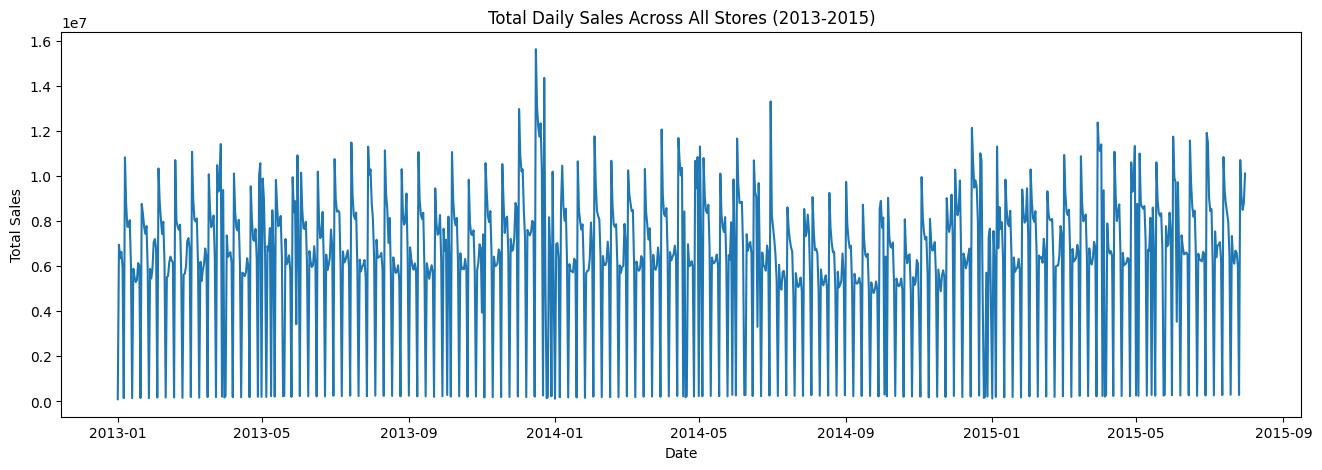

In [10]:
daily_total_sales = df.groupby('Date')['Sales'].sum().reset_index()

plt.figure(figsize=(16, 5))
plt.plot(daily_total_sales['Date'], daily_total_sales['Sales'])
plt.title('Total Daily Sales Across All Stores (2013-2015)')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.show()

Sales show strong, regular weekly cycling and no clear long-term upward or downward trend across the 2.5-year period. December stands out as the strongest month on average, consistent with a Christmas retail surge.

In [11]:
df['Month'] = df['Date'].dt.month
print(df.groupby('Month')['Sales'].mean())

Month
1     6563.690444
2     6589.165535
3     6976.412026
4     7046.228420
5     7106.453154
6     7000.978190
7     6952.682125
8     6648.984654
9     6546.343035
10    6602.843354
11    7188.554250
12    8608.956661
Name: Sales, dtype: float64


### Day-of-Week Patterns

Most stores do not trade on Sundays (only ~3,600 of ~844K open-store rows are Sundays, versus ~135-144K for other days), consistent with limited Sunday trading common among German retailers. The small number of stores that do open on Sundays show the highest average sales of any day likely a special, high-traffic subset of stores rather than Sundays being generally strong for sales. Among regularly-trading days, Monday shows the highest average sales.

                  mean   count
DayName                       
Monday     8216.073074  137560
Tuesday    7088.113656  143961
Wednesday  6728.122978  141936
Thursday   6767.310159  134644
Friday     7072.677012  138640
Saturday   5874.840238  144058
Sunday     8224.723908    3593


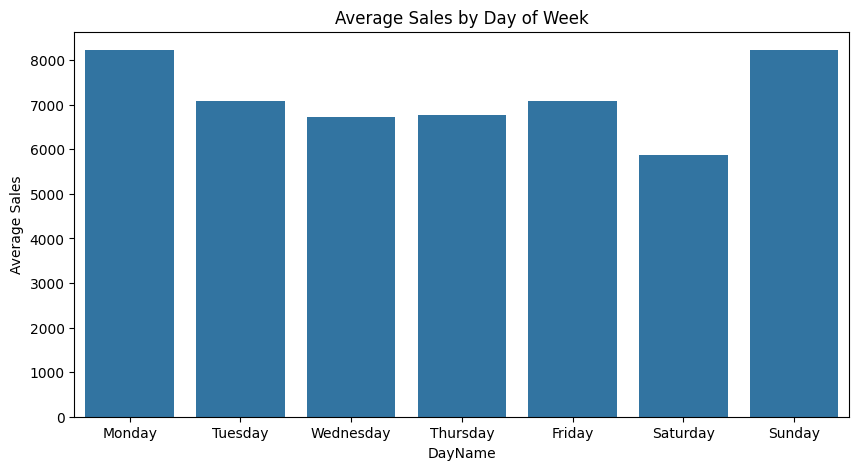

In [12]:
df['DayName'] = df['Date'].dt.day_name()
dow_sales = df.groupby('DayName')['Sales'].agg(['mean', 'count']).reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)
print(dow_sales)

plt.figure(figsize=(10, 5))
sns.barplot(x=dow_sales.index, y=dow_sales['mean'])
plt.title('Average Sales by Day of Week')
plt.ylabel('Average Sales')
plt.show()

### Promotion Effect

Running a promotion is associated with a substantial sales lift — average sales are ₦8,228 on promo days versus ₦5,929 without, a roughly 39% increase. This is correlational, not necessarily causal (stores may run promos when they already expect stronger demand), but the direction and magnitude align with expected retail behavior.

              mean   count
Promo                     
0      5929.407603  467496
1      8228.281239  376896


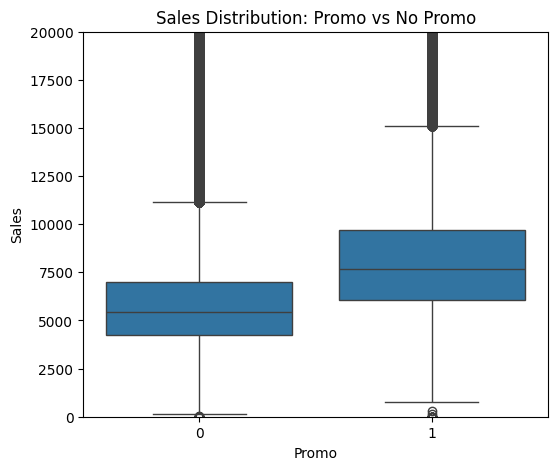

In [13]:
promo_sales = df.groupby('Promo')['Sales'].agg(['mean', 'count'])
print(promo_sales)

plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x='Promo', y='Sales')
plt.ylim(0, 20000)
plt.title('Sales Distribution: Promo vs No Promo')
plt.show()

### Store Type and Assortment

Store Type 'b' and Assortment 'b' both show notably higher average sales than other categories, but represent a small fraction of the data (~1.8% and ~1% of rows respectively) likely distinct store categories rather than evidence these types are broadly superior. This "small category, high average" pattern recurs across the dataset (Sunday sales, Store Type b, Assortment b) and warrants cautious interpretation.

                   mean   count
StoreType                      
b          10231.407505   15563
c           6932.512755  112978
a           6925.167661  457077
d           6822.141881  258774

                   mean   count
Assortment                     
b           8639.346322    8212
c           7300.526339  391271
a           6621.017039  444909


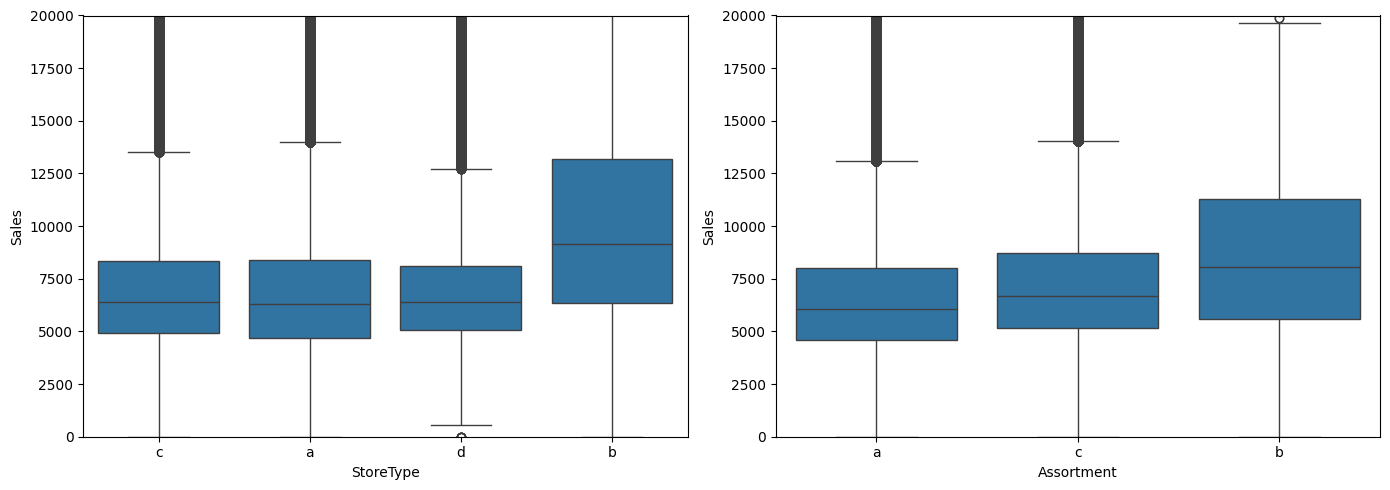

In [14]:
print(df.groupby('StoreType')['Sales'].agg(['mean', 'count']).sort_values('mean', ascending=False))
print()
print(df.groupby('Assortment')['Sales'].agg(['mean', 'count']).sort_values('mean', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='StoreType', y='Sales', ax=axes[0])
axes[0].set_ylim(0, 20000)
sns.boxplot(data=df, x='Assortment', y='Sales', ax=axes[1])
axes[1].set_ylim(0, 20000)
plt.tight_layout()
plt.show()

### Competition Distance

Distance to the nearest competitor shows almost no linear correlation with sales (r ≈ -0.036). This likely reflects competitors clustering in high-traffic commercial areas, where "close competition" and "good location" partially cancel each other out.

Correlation: -0.0363960889050029


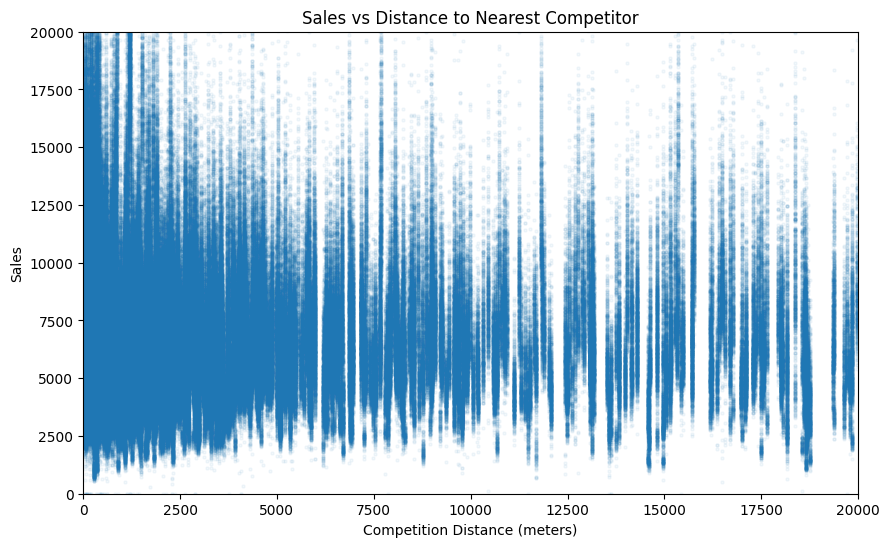

In [15]:
print("Correlation:", df['CompetitionDistance'].corr(df['Sales']))

plt.figure(figsize=(10, 6))
plt.scatter(df['CompetitionDistance'], df['Sales'], alpha=0.05, s=5)
plt.xlim(0, 20000)
plt.ylim(0, 20000)
plt.xlabel('Competition Distance (meters)')
plt.ylabel('Sales')
plt.title('Sales vs Distance to Nearest Competitor')
plt.show()

## Feature Engineering

Time series forecasting requires features that explicitly capture temporal patterns. Calendar features, lag features (sales N days ago), and a rolling average were built. Lag features were computed using calendar-date-based merges rather than simple row-based shifts, since closed-store days create gaps that would otherwise cause naive row-shifting to silently pull the wrong day's data.

In [16]:
df['Year'] = df['Date'].dt.year
df['Day'] = df['Date'].dt.day
df['WeekOfYear'] = df['Date'].dt.isocalendar().week
df['DayOfWeek'] = df['Date'].dt.dayofweek

df = df.sort_values(['Store', 'Date']).reset_index(drop=True)

In [17]:
# Lag 7 (calendar-date-based, correctly handles gaps from closed days)
lag_7_source = df[['Store', 'Date', 'Sales']].copy()
lag_7_source['Date'] = lag_7_source['Date'] + pd.Timedelta(days=7)
lag_7_source = lag_7_source.rename(columns={'Sales': 'Sales_Lag_7'})
df = df.merge(lag_7_source, on=['Store', 'Date'], how='left')

# Lag 14
lag_14_source = df[['Store', 'Date', 'Sales']].copy()
lag_14_source['Date'] = lag_14_source['Date'] + pd.Timedelta(days=14)
lag_14_source = lag_14_source.rename(columns={'Sales': 'Sales_Lag_14'})
df = df.merge(lag_14_source, on=['Store', 'Date'], how='left')

print(df[['Store', 'Date', 'Sales', 'Sales_Lag_7', 'Sales_Lag_14']].head(15))

    Store       Date  Sales  Sales_Lag_7  Sales_Lag_14
0       1 2013-01-02   5530          NaN           NaN
1       1 2013-01-03   4327          NaN           NaN
2       1 2013-01-04   4486          NaN           NaN
3       1 2013-01-05   4997          NaN           NaN
4       1 2013-01-07   7176          NaN           NaN
5       1 2013-01-08   5580          NaN           NaN
6       1 2013-01-09   5471       5530.0           NaN
7       1 2013-01-10   4892       4327.0           NaN
8       1 2013-01-11   4881       4486.0           NaN
9       1 2013-01-12   4952       4997.0           NaN
10      1 2013-01-14   4717       7176.0           NaN
11      1 2013-01-15   3900       5580.0           NaN
12      1 2013-01-16   4008       5471.0        5530.0
13      1 2013-01-17   4044       4892.0        4327.0
14      1 2013-01-18   4127       4881.0        4486.0


In [18]:
# Rolling 7-trading-day average, per store, using only past sales (shifted to avoid leakage)
def add_rolling_mean(store_df, window=7):
    store_df = store_df.set_index('Date').sort_index()
    store_df['Sales_Rolling_7'] = store_df['Sales'].rolling(window, min_periods=3).mean().shift(1)
    return store_df.reset_index()

df = df.groupby('Store', group_keys=False)[df.columns].apply(add_rolling_mean)
print(df[['Store', 'Date', 'Sales', 'Sales_Rolling_7']].head(10))

   Store       Date  Sales  Sales_Rolling_7
0      1 2013-01-02   5530              NaN
1      1 2013-01-03   4327              NaN
2      1 2013-01-04   4486              NaN
3      1 2013-01-05   4997      4781.000000
4      1 2013-01-07   7176      4835.000000
5      1 2013-01-08   5580      5303.200000
6      1 2013-01-09   5471      5349.333333
7      1 2013-01-10   4892      5366.714286
8      1 2013-01-11   4881      5275.571429
9      1 2013-01-12   4952      5354.714286


### Handling Missing Lag Features

Early rows in each store's timeline lack sufficient history to compute lag/rolling features. These rows (~8% of data) were dropped rather than imputed, since there is no genuine underlying value to estimate.

In [19]:
before = len(df)
df_features = df.dropna(subset=['Sales_Lag_7', 'Sales_Lag_14', 'Sales_Rolling_7']).copy()
print(f"Removed {before - len(df_features)} rows ({(before-len(df_features))/before*100:.2f}%)")
print(f"Remaining: {len(df_features)}")

Removed 69511 rows (8.23%)
Remaining: 774881


### Train/Test Split: Temporal, Not Random

A random split would let the model "see" future data during training, producing misleadingly optimistic results. Instead, the split is strictly by date training on earlier data, testing on the most recent 6 weeks simulating genuine forecasting use.

In [20]:
cutoff_date = df_features['Date'].max() - pd.Timedelta(weeks=6)

train = df_features[df_features['Date'] <= cutoff_date].copy()
test = df_features[df_features['Date'] > cutoff_date].copy()

print(f"Train: {train.shape}, {train['Date'].min()} to {train['Date'].max()}")
print(f"Test: {test.shape}, {test['Date'].min()} to {test['Date'].max()}")

Train: (734624, 26), 2013-01-15 00:00:00 to 2015-06-19 00:00:00
Test: (40257, 26), 2015-06-20 00:00:00 to 2015-07-31 00:00:00


## Modeling

Features include calendar features, lag features, rolling average, promotion status, holiday flags, and store metadata. `Customers` was deliberately excluded, since it would not genuinely be available at prediction time including it would be a form of leakage.

In [21]:
feature_cols = ['DayOfWeek', 'Month', 'Promo', 'SchoolHoliday', 'StateHoliday',
                 'StoreType', 'Assortment', 'CompetitionDistance',
                 'Sales_Lag_7', 'Sales_Lag_14', 'Sales_Rolling_7']
target_col = 'Sales'

X_train = train[feature_cols].copy()
y_train = train[target_col].copy()
X_test = test[feature_cols].copy()
y_test = test[target_col].copy()

fill_value = 100_000
X_train['CompetitionDistance'] = X_train['CompetitionDistance'].fillna(fill_value)
X_test['CompetitionDistance'] = X_test['CompetitionDistance'].fillna(fill_value)

categorical_features = ['DayOfWeek', 'Month', 'StoreType', 'Assortment', 'StateHoliday']
numeric_features = ['Promo', 'SchoolHoliday', 'CompetitionDistance',
                     'Sales_Lag_7', 'Sales_Lag_14', 'Sales_Rolling_7']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

### Baseline: Store + Day-of-Week Average

In [22]:
baseline_lookup = train.groupby(['Store', 'DayOfWeek'])['Sales'].mean()

def get_baseline_pred(row):
    key = (row['Store'], row['DayOfWeek'])
    return baseline_lookup.get(key, train['Sales'].mean())

baseline_pred = test.apply(get_baseline_pred, axis=1)

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print(f"Baseline — MAE: {baseline_mae:.2f}, RMSE: {baseline_rmse:.2f}, R²: {baseline_r2:.4f}")

Baseline — MAE: 1252.18, RMSE: 1660.07, R²: 0.7040


### Model Comparison

In [23]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=42)
}

results = []
fitted_pipelines = {}

for name, model in models.items():
    pipeline = Pipeline([('preprocessor', preprocessor), ('model', model)])
    pipeline.fit(X_train, y_train)
    pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R²': r2})
    fitted_pipelines[name] = pipeline
    print(f"{name} — MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.4f}")

results_df = pd.DataFrame(results)
print(results_df)

Linear Regression — MAE: 818.15, RMSE: 1142.10, R²: 0.8599
Random Forest — MAE: 668.73, RMSE: 993.70, R²: 0.8939
Gradient Boosting — MAE: 698.73, RMSE: 1035.37, R²: 0.8848
               Model         MAE         RMSE        R²
0  Linear Regression  818.151007  1142.100619  0.859877
1      Random Forest  668.730323   993.697472  0.893926
2  Gradient Boosting  698.729730  1035.373427  0.884842


All three models substantially outperform the baseline (R² 0.704). Random Forest performs best (R² 0.894, MAE 669)

## Evaluation

The best model (Random Forest) is examined in more depth: how predictions track actual sales over time, whether performance varies by store type, and which features matter most.

In [24]:
best_pipeline = fitted_pipelines['Random Forest']
best_pred = best_pipeline.predict(X_test)

test_results = test.copy()
test_results['Predicted_Sales'] = best_pred
test_results['Error'] = test_results['Sales'] - test_results['Predicted_Sales']
test_results['Abs_Error'] = np.abs(test_results['Error'])

### Actual vs Predicted Sales Over Time

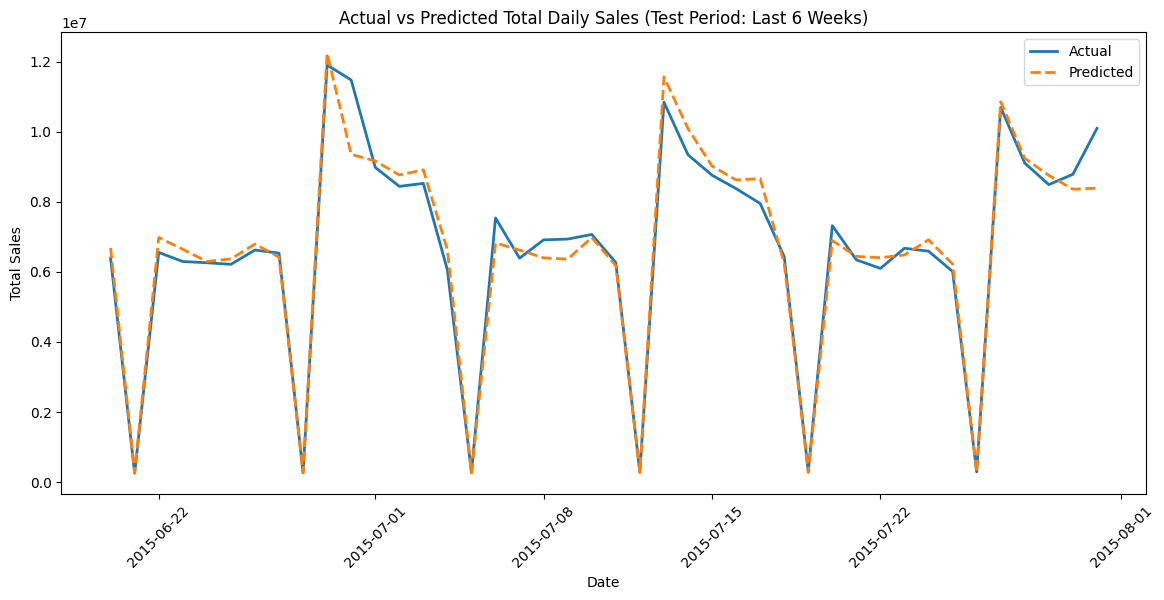

In [25]:
daily_comparison = test_results.groupby('Date')[['Sales', 'Predicted_Sales']].sum().reset_index()

plt.figure(figsize=(14, 6))
plt.plot(daily_comparison['Date'], daily_comparison['Sales'], label='Actual', linewidth=2)
plt.plot(daily_comparison['Date'], daily_comparison['Predicted_Sales'], label='Predicted', linewidth=2, linestyle='--')
plt.title('Actual vs Predicted Total Daily Sales (Test Period: Last 6 Weeks)')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.xticks(rotation=45)
plt.show()

The model closely tracks actual total daily sales, correctly capturing the strong weekly cycle including Sunday drops, rather than predicting a flat average.

### Error by Store Type

In [26]:
store_type_summary = test_results.groupby('StoreType').agg(
    avg_sales=('Sales', 'mean'),
    avg_abs_error=('Abs_Error', 'mean')
)
store_type_summary['pct_error'] = (store_type_summary['avg_abs_error'] / store_type_summary['avg_sales']) * 100
print(store_type_summary)

              avg_sales  avg_abs_error  pct_error
StoreType                                        
a           6871.204578     669.941426   9.749985
b          10808.666667     766.309522   7.089769
c           6885.941817     675.418901   9.808664
d           6977.090308     658.244777   9.434374


Prediction error is fairly consistent across store types (7-10%), suggesting the model generalizes well rather than overfitting to the most common store segment.

### Feature Importance

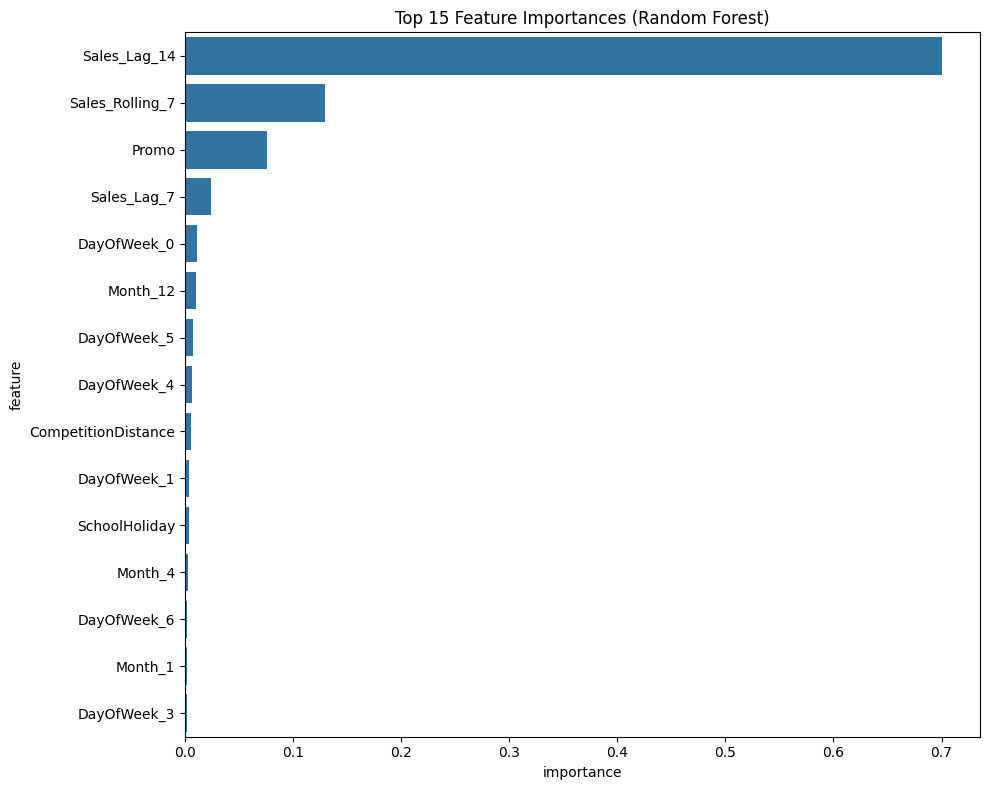

                feature  importance
34         Sales_Lag_14    0.700590
35      Sales_Rolling_7    0.129317
30                Promo    0.075445
33          Sales_Lag_7    0.024365
0           DayOfWeek_0    0.011257
18             Month_12    0.009818
5           DayOfWeek_5    0.007232
4           DayOfWeek_4    0.006323
32  CompetitionDistance    0.005354
1           DayOfWeek_1    0.003723
31        SchoolHoliday    0.003253
10              Month_4    0.002802
6           DayOfWeek_6    0.002052
7               Month_1    0.001892
3           DayOfWeek_3    0.001652


In [27]:
feature_names = (best_pipeline.named_steps['preprocessor']
                  .named_transformers_['cat']
                  .get_feature_names_out(categorical_features).tolist()
                  + numeric_features)
importances = best_pipeline.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df.head(15), x='importance', y='feature')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()

print(importance_df.head(15))

Engineered lag/rolling features dominate (~85% combined importance), validating the feature engineering approach. `Promo` is the strongest non-lag feature. `CompetitionDistance` contributes minimally, consistent with its near-zero correlation in EDA.

## Conclusion

This project built a sales forecasting model for a retail chain, predicting daily sales 6 weeks ahead. The best model (Random Forest) achieved R² = 0.894 and MAE ≈ 669 (roughly 9-10% of average daily sales), substantially outperforming a strong store-specific baseline (R² = 0.704).

**Key findings:**
- Recent sales history (lag/rolling features) drives ~85% of predictive power
- Promotions produce a genuine ~39% sales lift, well-captured by the model
- Performance is consistent across store types (7-10% error), indicating good generalization
- Strong weekly seasonality (especially limited Sunday trading) is correctly learned via lag features

**Methodology notes:**
- Used a strict temporal train/test split, essential for honest time-series evaluation
- Built lag features via calendar-date-based merges, correctly handling gaps from closed-store days
- Excluded `Customers` as a feature to avoid leakage (not genuinely available at prediction time)

**Limitations & Future Work:**
- Fixed 6-week forecast horizon; a production system would need to handle multiple horizons and refresh features with new data
- Competition distance was a weak predictor; competitor pricing/promotional data might add more value
- Could explore store clustering or dedicated time-series models (Prophet, SARIMA) for comparison

In [28]:
os.makedirs('models', exist_ok=True)
joblib.dump(best_pipeline, 'models/best_model.pkl')
print("Model saved.")

Model saved.


## Example Prediction

In [29]:
# Example: predict next-day sales for a sample store scenario
new_row = pd.DataFrame({
    'DayOfWeek': [1],
    'Month': [12],
    'Promo': [1],
    'SchoolHoliday': [0],
    'StateHoliday': ['0'],
    'StoreType': ['a'],
    'Assortment': ['a'],
    'CompetitionDistance': [1270.0],
    'Sales_Lag_7': [6000],
    'Sales_Lag_14': [5800],
    'Sales_Rolling_7': [5900]
})

predicted_sales = best_pipeline.predict(new_row)[0]
print(f"Predicted sales: {predicted_sales:,.0f}")

Predicted sales: 7,238


##Lean Model
The model size was reduced because of the size wgen tryig to push to my github

In [30]:
from sklearn.ensemble import RandomForestRegressor

lean_model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
lean_pipeline = Pipeline([('preprocessor', preprocessor), ('model', lean_model)])
lean_pipeline.fit(X_train, y_train)

lean_pred = lean_pipeline.predict(X_test)
print("Lean model R²:", r2_score(y_test, lean_pred))
print("Lean model MAE:", mean_absolute_error(y_test, lean_pred))

joblib.dump(lean_pipeline, 'models/best_model.pkl', compress=3)
print("Size (MB):", os.path.getsize('models/best_model.pkl') / (1024*1024))

Lean model R²: 0.8866870614749864
Lean model MAE: 697.5717181336992
Size (MB): 2.467121124267578
